In [6]:
import numpy as np 
import pandas as pd

In [7]:
df = pd.read_csv(r"C:\Users\Dr.Sumedha\Downloads\placement.csv") 
df.head()


,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


# Steps 


In [8]:
df.info() # har ak coloum ka information dete hain .

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [9]:
df = df.iloc[:,1:]  # 
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [10]:
import matplotlib.pyplot as plt

Index(['cgpa', 'iq', 'placement'], dtype='object')


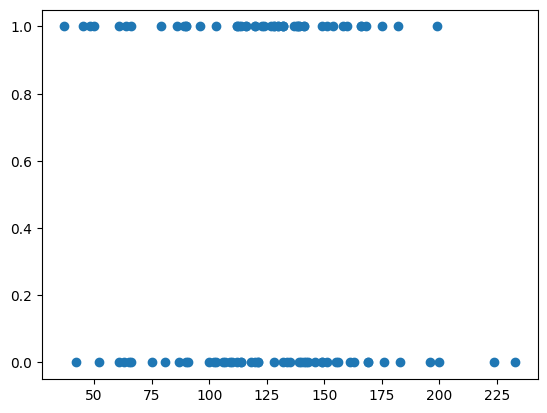

In [11]:
import matplotlib.pyplot as plt
%matplotlib inline

print(df.columns)   # always check first

plt.scatter(df["iq"], df["placement"])
plt.show()

In [12]:
x  = df.iloc[:,0:2] # cgpa and iq print hoga yeha placement nehi hoga.
y = df.iloc[:,-1]  # aur ye placement print karega.

In [13]:
x  # 2D tensor

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [14]:
y

0     1
1     0
2     0
3     1
4     0
     ..
95    0
96    0
97    1
98    1
99    1
Name: placement, Length: 100, dtype: int64

In [15]:
y.shape # 1D tensor 

(100,)

In [16]:
!pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
X = df[["iq"]]
y = df["placement"]

# Split data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42
)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)



(90, 1)
(10, 1)
(90,)
(10,)


In [18]:
X_train

,iq
18,100.0
30,128.0
73,61.0
33,149.0
90,86.0
...,...
60,139.0
71,132.0
14,103.0
92,110.0


In [19]:
y_train  # x ke corrsponding data y main hain. here pehle wali student ke placement nehi huwa hain. aur also 3rd and 4th .

18    0
30    1
73    0
33    0
90    1
     ..
60    1
71    1
14    0
92    0
51    0
Name: placement, Length: 90, dtype: int64

In [20]:
from sklearn.preprocessing import StandardScaler  # scaling karne ke liye wapas sklearn main ghusna parega aur preprocessing main jana parega jaha ak class hain woh hain StandardScaler.

In [21]:
scaler = StandardScaler() # Iss class ka ak object banaya aur usko scale kar dena hain.

In [22]:
X_train = scaler.fit_transform(X_train) # transform pehle dekhega ki data main kiya hain aur thn transform kar dega.

In [23]:
X_train

array([[-0.62029848],
       [ 0.09806189],
       [-1.62087186],
       [ 0.63683217],
       [-0.97947867],
       [ 0.45724208],
       [ 0.79076654],
       [-1.90308486],
       [ 0.3802749 ],
       [-0.38939693],
       [-0.26111829],
       [ 0.63683217],
       [ 1.91961855],
       [-0.90251149],
       [-0.10718393],
       [ 1.32953682],
       [ 0.25199626],
       [-2.10833068],
       [-1.49259322],
       [-0.20980684],
       [ 0.35461917],
       [ 0.9447009 ],
       [ 1.07297954],
       [-0.87685576],
       [-0.31242975],
       [-1.95439632],
       [-0.72292139],
       [ 1.07297954],
       [-0.87685576],
       [ 2.56101175],
       [ 0.27765199],
       [ 0.99601236],
       [-1.5695604 ],
       [ 1.94527428],
       [-0.00456102],
       [ 0.2006848 ],
       [-0.44070839],
       [-0.85120003],
       [-0.56898703],
       [-0.20980684],
       [-0.0815282 ],
       [ 0.2006848 ],
       [ 1.50912691],
       [ 0.91904518],
       [ 0.81642227],
       [-1

In [24]:
X_test = scaler.transform(X_test)
X_test

array([[ 0.14937335],
       [ 1.124291  ],
       [ 0.07240616],
       [-1.49259322],
       [-1.62087186],
       [ 0.55986499],
       [-0.10718393],
       [ 1.84265137],
       [-2.0313635 ],
       [-0.03021675]])

In [25]:
from sklearn.linear_model import LogisticRegression 

In [26]:
clf = LogisticRegression()

In [27]:
# model training 
clf.fit(X_train,y_train)  # clf ke pass ak power hain jo LogisticRegression class ke under ki function ko access karna. fit ko use karte hain model ko train karne ke liye.
                            # Aur yeha traing data provide liya hain.

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [28]:
clf.predict(X_test)  # yee model galat bol rahi hain kioki 6th wali ki placement ho geyi hain but model bol raha hain ki ne

array([0, 0, 0, 0, 0, 0, 0, 0, 1, 0])

In [29]:
y_test

83    1
53    1
70    1
45    1
44    1
39    0
22    0
80    0
10    1
0     1
Name: placement, dtype: int64

In [30]:
# ak function ko call karna hain jo metrics ke under hain jiska name hain accuracy_score
from sklearn.metrics import accuracy_score

In [32]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Load data
X, y = load_iris(return_X_y=True)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

# Create y_pred
y_pred = model.predict(X_test)

# Accuracy
print(accuracy_score(y_test, y_pred))# aur accuracy_score main jo sehi wala data hain woh batana hota hain aur prediction batana hota hain.

1.0


# How to Frame a Machine Learnig Problem->

# Business Problem to ML Problem -> # Churn rate

# Type of Problem -> # Big picture aur thn end product kia hoga  and churn rate reduce karna matlab unn customar ko rok pao jo chor ke chala geya hain.churn rate prediction nehi karna hain woh kisi aur ka kam hain hamara kam hain un logo ko rokhna jo jane wala hain.yeha ye pata krna hain ki kon log sorke jane wala hain.mujhe rokne ke liye kuch toh karna hain mujhe kia karna hain ye mujhe decision making karna hain aur unka problem pata karna hain mujhe.

# 3. Current Solution -> Iss case main upar CTO se baat karna hain aur pata chalta hain ki akk existing solution toh hain aur woh overall churn rate batate hain.

# 4.  Getting Data -> yeha data kaha se ayega  aur usme kaisa data chahiye aur data main kiya kiya columns hone chahiye.

# 1. Watch time 
# 2. Search but did not find 
# 3.Content left in the middle
# 4.Clicked on recommendations(order of recommendation) 

# 5. Metrics to measure -> metrics guide karte hain ki 6 month se jo kar rahi ho woh sehi hain kiya nehi .
# 6.Online Vs Batch -> 
# 7. Check Assumptions ->

# Importing pandas

In [3]:
import pandas as pd

In [6]:
df = pd.read_csv(r"C:\Users\Dr.Sumedha\Downloads\aug_train.csv")
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0


# Opening a csv file from an URL ->

In [ ]:
import requests
from io import StringIO

url = ""
headers = {"User-Agent": }